# MP1 - Last.fm API with pandas


**Research question #1:** Top Last.fm artists by profile country (US, Brazil, South Korea) and how much those charts overlap (geographic bias).

**Research question #2:** Which **genres** (Last.fm **tags**) have the most **listeners**, using each tag’s **`reach`** on the platform.


In [2]:
import json
import os
import time
import urllib.parse
import urllib.request
from pathlib import Path
import sys
sys.executable

import pandas as pd


def _parse_env_file(path: Path) -> dict:
    """Parse KEY=VALUE lines (works without python-dotenv)."""
    out = {}
    if not path.is_file():
        return out
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        if "=" not in line:
            continue
        key, _, val = line.partition("=")
        key = key.strip()
        val = val.strip().strip('"').strip("'")
        if key:
            out[key] = val
    return out


def _candidate_env_paths() -> list[Path]:
    cwd = Path.cwd()
    paths = [
        cwd / ".env",
        cwd / "Week 5" / "A5: Pandas Assignment" / ".env",
        cwd / "A5: Pandas Assignment" / ".env",
    ]
    for parent in [cwd, *list(cwd.parents)[:10]]:
        paths.append(parent / "Week 5" / "A5: Pandas Assignment" / ".env")
        paths.append(parent / ".env")
    seen: set[Path] = set()
    uniq: list[Path] = []
    for p in paths:
        try:
            rp = p.resolve()
        except OSError:
            continue
        if rp not in seen:
            seen.add(rp)
            uniq.append(p)
    return uniq


def resolve_lastfm_api_key() -> str:
    key = (os.environ.get("LASTFM_API_KEY") or "").strip()
    if key:
        return key
    try:
        from dotenv import load_dotenv  # pyright: ignore[reportMissingImports]

        for p in _candidate_env_paths():
            if p.is_file():
                load_dotenv(p)
                break
        key = (os.environ.get("LASTFM_API_KEY") or "").strip()
        if key:
            return key
    except ImportError:
        pass
    for p in _candidate_env_paths():
        data = _parse_env_file(p)
        key = (data.get("LASTFM_API_KEY") or "").strip()
        if key:
            return key
    raise ValueError(
        "LASTFM_API_KEY is missing or empty. Edit .env in this folder and set:\n"
        "  LASTFM_API_KEY=your_key\n"
        "(no spaces around =). Or: export LASTFM_API_KEY=your_key"
    )


API_KEY = resolve_lastfm_api_key()
BASE = "https://ws.audioscrobbler.com/2.0/"


def lastfm_call(method: str, extra: dict | None = None) -> dict:
    params = {"method": method, "api_key": API_KEY, "format": "json"}
    if extra:
        params.update(extra)
    url = BASE + "?" + urllib.parse.urlencode(params)
    with urllib.request.urlopen(url, timeout=30) as resp:
        payload = json.load(resp)
    err = payload.get("error")
    if err is not None:
        msg = payload.get("message", str(payload))
        raise RuntimeError("Last.fm API error {}: {}".format(err, msg))
    return payload


print("pandas:", pd.__version__)


pandas: 3.0.2


## **Research Question #1:** Who are the top 20 artists on Last.fm in the United States, Brazil, and South Korea?
Fetch top artists by country

Uses [`geo.getTopArtists`](https://www.last.fm/api/show/geo.getTopArtists) with `limit=20`. The next cell calls the API for all three countries, then builds **`df`** with columns **`country_label`**, **`name`**, and **`listeners`** only.

Country names must match what Last.fm expects (ISO-style). **Error 6 `country param invalid`** means the string was not recognized; the code tries common alternates (e.g. `Korea, Republic of` for South Korea).

Rankings reflect **Last.fm chart popularity** in that country, not global sales or streams elsewhere.



In [3]:
import time

import pandas as pd
from lastfm_api import lastfm_call

# I wanted to compare the top artists in the US, Brazil, and South Korea
# I set the parameters for the api call to those three countries and set a limit to 20 artists
COUNTRY_QUERY = [
    # Last.fm expects ISO-style country names; if one fails, we try alternates.
    ("United States", ["United States", "United States of America"]),
    ("Brazil", ["Brazil"]),
    ("South Korea", ["Korea, Republic of", "South Korea"]),
]
LIMIT = 20
parts = []
for label, country_options in COUNTRY_QUERY:
    payload = None
    used_param = None
    for country_param in country_options:
        try:
            payload = lastfm_call(
                "geo.gettopartists",
                {"country": country_param, "limit": LIMIT},
            )
            used_param = country_param
            break
        except RuntimeError as exc:
            err_text = str(exc)
            if "error 6" in err_text and "country param invalid" in err_text:
                continue
            raise
    if payload is None:
        raise RuntimeError(
            "Could not resolve country name for {!r}. Tried: {}".format(
                label, country_options
            )
        )

    artists = payload["topartists"]["artist"]
    if isinstance(artists, dict):
        artists = [artists]
    chunk = pd.json_normalize(artists)
    chunk.insert(0, "country_label", label)
    chunk.insert(1, "country_param", used_param)
    parts.append(chunk)
    time.sleep(0.3)

#I used the concat function to combine the parts into a single dataframe
geo_top_artists = pd.concat(parts, ignore_index=True)

#I defined df to be geo_top_artists to make it easier to code with
#the columns were labeled to be country_label, name, and listeners
df = geo_top_artists.copy()
TABLE_COLS = ["country_label", "name", "listeners"]
TABLE_COLS = [c for c in TABLE_COLS if c in df.columns]
if "listeners" in df.columns:
    df["listeners"] = pd.to_numeric(df["listeners"], errors="coerce")

#this is the last line, showing that the table is the cell output
df[TABLE_COLS]


,country_label,name,listeners
0,United States,Kanye West,242926
1,United States,Drake,238213
2,United States,Kendrick Lamar,228488
3,United States,"Tyler, The Creator",228055
4,United States,PinkPantheress,214472
5,United States,Radiohead,206407
6,United States,The Weeknd,198587
7,United States,Rihanna,198126
8,United States,Tame Impala,191412
9,United States,Michael Jackson,186669


## Countries as columns (side‑by‑side)

Each country still has **20 artists**, so rows are **rank** (1 = top on Last.fm for that country). There are two tables: **artist names** and **listener counts**, both with the same country column headers.

If you need every artist’s name and listeners in **one** grid, merge those two tables into one sheet in Excel or stack them vertically below.


In [4]:
try:
    from IPython.display import display
except ImportError:
    def display(*xs):
        for x in xs:
            print(x)
#I made a copy of df so that I can add columns without affecting the original df
_df = df.copy()
_df["rank"] = _df.groupby("country_label", sort=False).cumcount() + 1
#I used the pivot function to create one table that focused on the top artists of each country

# I wanted to just show the top 10 artists to make the table more concise
# I defined TOP_N to be 10 and used the head function to only show the top 10 artists
TOP_N = 10

names_by_country = _df.pivot(index="rank", columns="country_label", values="name").head(TOP_N)
#I printed the two tables to the console
print("Artist names (columns = country)")
display(names_by_country)




Artist names (columns = country)


country_label,Brazil,South Korea,United States
rank,,,
1,Lady Gaga,Justin Bieber,Kanye West
2,Sabrina Carpenter,Kanye West,Drake
3,Ariana Grande,ILLIT,Kendrick Lamar
4,Taylor Swift,The Weeknd,"Tyler, The Creator"
5,Marina Sena,Kendrick Lamar,PinkPantheress
6,Anitta,BTS,Radiohead
7,Lana Del Rey,LE SSERAFIM,The Weeknd
8,Michael Jackson,Ariana Grande,Rihanna
9,The Weeknd,NewJeans,Tame Impala


In [5]:
try:
    from IPython.display import display
except ImportError:
    display = print

for label in df["country_label"].unique():
    sub = df.loc[df["country_label"].eq(label), TABLE_COLS]
    print()
    print("===", label, "===")
    display(sub.reset_index(drop=True))



=== United States ===


,country_label,name,listeners
0,United States,Kanye West,242926
1,United States,Drake,238213
2,United States,Kendrick Lamar,228488
3,United States,"Tyler, The Creator",228055
4,United States,PinkPantheress,214472
5,United States,Radiohead,206407
6,United States,The Weeknd,198587
7,United States,Rihanna,198126
8,United States,Tame Impala,191412
9,United States,Michael Jackson,186669



=== Brazil ===


,country_label,name,listeners
0,Brazil,Lady Gaga,117912
1,Brazil,Sabrina Carpenter,107347
2,Brazil,Ariana Grande,104454
3,Brazil,Taylor Swift,103022
4,Brazil,Marina Sena,100823
5,Brazil,Anitta,98481
6,Brazil,Lana Del Rey,97000
7,Brazil,Michael Jackson,96004
8,Brazil,The Weeknd,94252
9,Brazil,Rihanna,90366



=== South Korea ===


,country_label,name,listeners
0,South Korea,Justin Bieber,786
1,South Korea,Kanye West,744
2,South Korea,ILLIT,707
3,South Korea,The Weeknd,638
4,South Korea,Kendrick Lamar,636
5,South Korea,BTS,625
6,South Korea,LE SSERAFIM,622
7,South Korea,Ariana Grande,594
8,South Korea,NewJeans,593
9,South Korea,Drake,589


## RQ1 (reiterated) — Geographic representativeness on Last.fm

**New Research Question 1:** Among Last.fm users who set their **profile country** to the United States, Brazil, or South Korea, how **similar** are the platform’s **top-artist** charts—and what do those patterns suggest about Last.fm’s **geographic bias**?

**Why a second part (after Part 1)?** Part 1 answers the API literally: who ranks on each country’s chart. While doing that, it became clear Last.fm’s **geo** data are **heavily skewed**. `geo.getTopArtists` is driven by **profile country** that users set—not IP address, citizenship, or a representative national sample. In places where Last.fm’s **active userbase is tiny** (e.g. South Korea), the chart can look like **global mainstream** acts (e.g. Justin Bieber at #1) rather than what domestic charts or typical streaming habits in that country would suggest. That pattern fits **a small, non-representative slice** of users—often internationally oriented or tech-savvy listeners who chose that location—not “what everyone in that country listens to.” So Part 1 stays as a **straight API reference** for the professor; **Part 2 adds a comparative lens** (overlap between charts, shared mega-stars across “countries”) to show **platform geography bias** rather than pretending each chart equals national taste.

**How to run this section:** Run the notebook **from the top** through the Part 1 **geo fetch** cell (the one that builds `df`) **before** you run the code cell below. You do **not** need to keep restarting the kernel—only restart if you change your API key in `.env`, switch Python environments, or want a completely fresh session.

**Data caveat:** `geo.getTopArtists` uses **self-reported profile location**, not IP geolocation or national listening surveys.


In [6]:
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

if "df" not in globals():
    raise RuntimeError(
        "Run the Part 1 **geo fetch** cell first (it creates `df`). "
        "Use Run All from the top, or run setup then geo fetch. "
        "You do not need to restart the kernel unless you changed `.env` or need a clean slate."
    )

# --- overlap / similarity analysis (uses df from Part 1) ---

#I wanted to compare the similarity or overlapping artists of two countries
#I defined a function to calculate the jaccard similarity between those two sets
def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    union = a | b
    if not union:
        return 0.0
    return len(a & b) / len(union)

#I created a dictionary of sets of artists for each country
_sets = {
    label: set(df.loc[df["country_label"].eq(label), "name"].astype(str))
    for label in sorted(df["country_label"].unique())
}
countries = list(_sets.keys())

#I printed the number of artists in each country
print("Top-chart artist counts by profile country:", {k: len(v) for k, v in _sets.items()})

#I created a list of pairs of countries to compare
pair_rows = []
for i, c1 in enumerate(countries):
    for c2 in countries[i + 1 :]:
        pair_rows.append(
            {
                "profile_country_a": c1,
                "profile_country_b": c2,
                "overlap_artists": len(_sets[c1] & _sets[c2]),
                "jaccard_similarity": round(jaccard(_sets[c1], _sets[c2]), 4),
            }
        )

#I created a dataframe of the pairwise overlap
pairwise_df = pd.DataFrame(pair_rows)
print("\nPairwise overlap (same artist name on both charts):")
display(pairwise_df)

#I created a set of artists that appear on the top chart for all three profile countries
all_three = set.intersection(*_sets.values()) if len(_sets) >= 1 else set()
print(
    f"\nArtists on the top chart for ALL three profile countries ({len(all_three)} total):"
)
print(sorted(all_three))

#I created a list of artists that appear only on one country's chart
unique_rows = []
for c in countries:
    others = (
        set.union(*[_sets[o] for o in countries if o != c])
        if len(countries) > 1
        else set()
    )
    only_here = sorted(_sets[c] - others)
    unique_rows.append(
        {
            "profile_country": c,
            "artists_only_on_this_chart": len(only_here),
            "examples": ", ".join(only_here[:8]) + ("..." if len(only_here) > 8 else ""),
        }
    )

unique_df = pd.DataFrame(unique_rows)
print("\nArtists that appear only on one country's chart (among these top lists):")
display(unique_df)


Top-chart artist counts by profile country: {'Brazil': 20, 'South Korea': 20, 'United States': 20}

Pairwise overlap (same artist name on both charts):


,profile_country_a,profile_country_b,overlap_artists,jaccard_similarity
0,Brazil,South Korea,10,0.3333
1,Brazil,United States,12,0.4286
2,South Korea,United States,15,0.6000



Artists on the top chart for ALL three profile countries (10 total):
['Ariana Grande', 'Charli xcx', 'Justin Bieber', 'Lady Gaga', 'PinkPantheress', 'Sabrina Carpenter', 'Tame Impala', 'Taylor Swift', 'The Weeknd', 'Tyler, The Creator']

Artists that appear only on one country's chart (among these top lists):


,profile_country,artists_only_on_this_chart,examples
0,Brazil,8,"Anitta, Arctic Monkeys, Beyoncé, Billie Eilish..."
1,South Korea,5,"BTS, CORTIS, ILLIT, LE SSERAFIM, NewJeans"
2,United States,3,"Childish Gambino, Malcolm Todd, Paramore"


## Research Question 2 — Which genres have the most listeners?

**What the API measures:** Last.fm uses **tags** (loosely like genres), not a perfect genre tree. **“Listeners”** here means the **`reach`** field: how many users are associated with that tag ([`tag.getInfo`](https://www.last.fm/api/show/tag.getInfo)). We also show **`taggings`** (how often the tag was used). This section uses **`chart.getTopTags`** (global tag chart).

Run the **setup** cell first so `lastfm_call` and `pandas` are loaded.


In [7]:
import pandas as pd
from lastfm_api import lastfm_call

LIMIT_TAGS = 50

payload = lastfm_call("chart.gettoptags", {"limit": LIMIT_TAGS})
tags_raw = payload["tags"]["tag"]
if isinstance(tags_raw, dict):
    tags_raw = [tags_raw]

tags_df = pd.json_normalize(tags_raw)
for col in ("reach", "taggings"):
    if col in tags_df.columns:
        tags_df[col] = pd.to_numeric(tags_df[col], errors="coerce")

tags_df = tags_df.sort_values("reach", ascending=False, na_position="last").reset_index(drop=True)

out_cols = [c for c in ("name", "reach", "taggings") if c in tags_df.columns]
tags_df[out_cols].head(20)


,name,reach,taggings
0,rock,403030,4070901
1,alternative,267280,2131504
2,electronic,262384,2501484
3,indie,260558,2066005
4,pop,233904,2084519
5,alternative rock,170338,1232171
6,female vocalists,169184,1634893
7,metal,159073,1306376
8,folk,151408,959820
9,ambient,150311,1127209


In [8]:
import matplotlib.pyplot as plt

if "tags_df" not in globals():
    raise RuntimeError(
        "Run the cell above that fetches chart.getTopTags (defines tags_df) first."
    )
tags_df = globals()["tags_df"]

top_n = 15
plot_df = tags_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
ax.barh(plot_df["name"].astype(str), plot_df["reach"])
ax.set_xlabel("reach (Last.fm users)")
ax.set_title("Top tags by reach — chart.getTopTags")
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'matplotlib'

### Limitations (Research Question 2)

Tags are not a full genre system. **`reach`** is a Last.fm platform metric, not global streaming counts. Rankings change over time.


## Research Question 3 — Play-to-listener ratio by genre (tags)

**Population:** The first **100** artists from Last.fm’s global weekly chart ([`chart.getTopArtists`](https://www.last.fm/api/show/chart.getTopArtists)), paginated in one snapshot.

**Genre proxy:** **Genre ≡ primary Last.fm tag** — we use each artist’s **first tag** from [`artist.getTopTags`](https://www.last.fm/api/show/artist.getTopTags) (ordered by consensus). Tags are not a formal genre taxonomy.

**Plays / listeners:** **`playcount`** and **`listeners`** come from [`artist.getInfo`](https://www.last.fm/api/show/artist.getInfo) for every artist (single consistent source).

**Play-to-listener ratio** (per artist \(i\)): \(r_i = \text{playcount}_i / \text{listeners}_i\) after coercing to numbers. Artists with missing, zero, or invalid **`listeners`** are excluded (count printed).

**By-genre summaries:**
1. **Median \(r_i\)** per **`genre_tag`** (robust to outliers).
2. **Weighted ratio:** \(\sum \text{playcount} / \sum \text{listeners}\) among artists sharing that primary tag.

Only tags with at least **`MIN_ARTISTS_PER_TAG`** artists are kept for ranking so one artist cannot define a “genre.”

Run the **setup** cell first (`lastfm_call`, `pandas`, `time`).

In [9]:
import pandas as pd
from pathlib import Path
from lastfm_api import lastfm_call

# --- RQ3: global chart top 100 (paginated) ---
RQ3_TARGET_N = 100
RQ3_PAGE_SIZE = 50  # Last.fm chart default page size; increase cautiously if API allows

_chart_parts: list[pd.DataFrame] = []
_page = 1
while sum(len(p) for p in _chart_parts) < RQ3_TARGET_N:
    payload = lastfm_call(
        "chart.gettopartists",
        {"limit": RQ3_PAGE_SIZE, "page": _page},
    )
    artists_raw = payload["artists"]["artist"]
    if isinstance(artists_raw, dict):
        artists_raw = [artists_raw]
    if not artists_raw:
        break
    _chart_parts.append(pd.json_normalize(artists_raw))
    _page += 1
    if len(artists_raw) < RQ3_PAGE_SIZE:
        break

chart100_raw = pd.concat(_chart_parts, ignore_index=True).head(RQ3_TARGET_N)

# Dedupe: prefer MBID when present, else normalized artist name
_name = chart100_raw["name"].astype(str).str.strip()
if "mbid" in chart100_raw.columns:
    _mbid = chart100_raw["mbid"].astype(str).str.strip()
    _mbid = _mbid.replace({"nan": "", "None": ""})
else:
    _mbid = pd.Series([""] * len(chart100_raw))
chart100_raw["_dedupe_key"] = _mbid.where(_mbid.ne(""), _name.str.lower())
chart100_df = chart100_raw.drop_duplicates(subset=["_dedupe_key"], keep="first").drop(
    columns=["_dedupe_key"]
)
chart100_df = chart100_df.reset_index(drop=True)

_RQ3_CHART_PKL = Path("rq3_chart100_df.pkl")
chart100_df.to_pickle(_RQ3_CHART_PKL)
print(f"Saved chart100_df to {_RQ3_CHART_PKL} (RQ3 enrichment can load this after Kernel → Restart).")

print(
    f"Chart rows fetched (pre-dedupe head limit {RQ3_TARGET_N}): {len(chart100_raw)}",
    f"→ unique artists: {len(chart100_df)}",
    sep="\n",
)
chart100_df[["name", "mbid"]].head(10)

Saved chart100_df to rq3_chart100_df.pkl (RQ3 enrichment can load this after Kernel → Restart).
Chart rows fetched (pre-dedupe head limit 100): 100
→ unique artists: 99


,name,mbid
0,The Weeknd,c8b03190-306c-4120-bb0b-6f2ebfc06ea9
1,Kanye West,NaN
2,Lady Gaga,650e7db6-b795-4eb5-a702-5ea2fc46c848
3,PinkPantheress,7441014f-f8f5-494f-81db-ff166fbc078d
4,Justin Bieber,e0140a67-e4d1-4f13-8a01-364355bee46e
5,Tame Impala,63aa26c3-d59b-4da4-84ac-716b54f1ef4d
6,Rihanna,73e5e69d-3554-40d8-8516-00cb38737a1c
7,Drake,9fff2f8a-21e6-47de-a2b8-7f449929d43f
8,Michael Jackson,f27ec8db-af05-4f36-916e-3d57f91ecf5e
9,Kendrick Lamar,381086ea-f511-4aba-bdf9-71c753dc5077


In [ ]:
import time
from pathlib import Path

import pandas as pd
from lastfm_api import lastfm_call

# --- RQ3: artist.getInfo + artist.getTopTags (primary tag) ---
# Prerequisite: run the **RQ3 chart** cell above first (it builds `chart100_df`).
# After Kernel → Restart, run that chart cell again before this one.
RQ3_API_DELAY = 0.25  # seconds between calls to reduce throttling
_rq3_counts = {"no_listeners": 0, "no_tags": 0, "api_errors": 0}


def _pick_artist_params(row: pd.Series) -> dict:
    mbid = row.get("mbid")
    if mbid is None or (isinstance(mbid, float) and pd.isna(mbid)):
        mbid = ""
    else:
        mbid = str(mbid).strip()
    if mbid and mbid.lower() != "nan":
        return {"mbid": mbid}
    return {"artist": str(row["name"]).strip()}


def _parse_play_listeners(info_payload: dict) -> tuple[float | None, float | None]:
    a = info_payload.get("artist") or {}
    pc = a.get("playcount")
    ls = a.get("listeners")
    stats = a.get("stats") or {}
    if pc is None:
        pc = stats.get("playcount")
    if ls is None:
        ls = stats.get("listeners")
    pc_n = pd.to_numeric(pc, errors="coerce")
    ls_n = pd.to_numeric(ls, errors="coerce")
    return pc_n, ls_n


def _primary_genre_tag(tags_payload: dict) -> str | None:
    tt = tags_payload.get("toptags") or {}
    raw = tt.get("tag")
    if raw is None:
        return None
    if isinstance(raw, dict):
        raw = [raw]
    if not raw:
        return None
    first = raw[0]
    if isinstance(first, dict):
        return first.get("name")
    return None


_RQ3_CHART_PKL = Path("rq3_chart100_df.pkl")
if "chart100_df" not in globals():
    if _RQ3_CHART_PKL.is_file():
        chart100_df = pd.read_pickle(_RQ3_CHART_PKL)
        print(
            f"Loaded chart100_df from {_RQ3_CHART_PKL} — re-run the chart cell above for fresh data."
        )
    else:
        raise RuntimeError(
            "chart100_df is missing. Run the RQ3 chart cell above first (chart.gettopartists). "
            "That cell saves rq3_chart100_df.pkl so enrichment can resume after a kernel restart."
        )

_rows: list[dict] = []
for _, row in chart100_df.iterrows():
    params_base = _pick_artist_params(row)
    time.sleep(RQ3_API_DELAY)
    try:
        info_pl = lastfm_call("artist.getinfo", params_base)
        playcount, listeners = _parse_play_listeners(info_pl)
    except RuntimeError:
        _rq3_counts["api_errors"] += 1
        continue

    if listeners is None or listeners <= 0 or pd.isna(listeners):
        _rq3_counts["no_listeners"] += 1
        continue
    if playcount is None or pd.isna(playcount):
        playcount = 0.0

    time.sleep(RQ3_API_DELAY)
    try:
        tags_pl = lastfm_call("artist.gettoptags", params_base)
        gtag = _primary_genre_tag(tags_pl)
    except RuntimeError:
        _rq3_counts["api_errors"] += 1
        continue

    if not gtag:
        _rq3_counts["no_tags"] += 1
        continue

    ratio = float(playcount) / float(listeners)
    _rows.append(
        {
            "name": row["name"],
            "mbid": row.get("mbid"),
            "playcount": float(playcount),
            "listeners": float(listeners),
            "play_per_listener": ratio,
            "genre_tag": str(gtag),
        }
    )

rq3_artists_df = pd.DataFrame(_rows)
_RQ3_ARTISTS_PKL = Path("rq3_artists_df.pkl")
rq3_artists_df.to_pickle(_RQ3_ARTISTS_PKL)
print(
    f"Saved rq3_artists_df to {_RQ3_ARTISTS_PKL} (viz cell can reload after Kernel → Restart).",
    sep="\n",
)
print(
    f"RQ3 artists with valid ratio + primary tag: {len(rq3_artists_df)}",
    f"excluded (no listeners): {_rq3_counts['no_listeners']}",
    f"excluded (no tags): {_rq3_counts['no_tags']}",
    f"API errors skipped: {_rq3_counts['api_errors']}",
    sep="\n",
)
rq3_artists_df.head(10)


,genre_tag,median_play_per_listener,weighted_play_per_listener,n_artists
0,rnb,138.946314,150.845459,6
1,Hip-Hop,122.964012,140.319568,11
2,pop,107.500387,105.699655,23
4,rock,103.920436,109.857245,5
6,indie,80.909842,125.877521,6


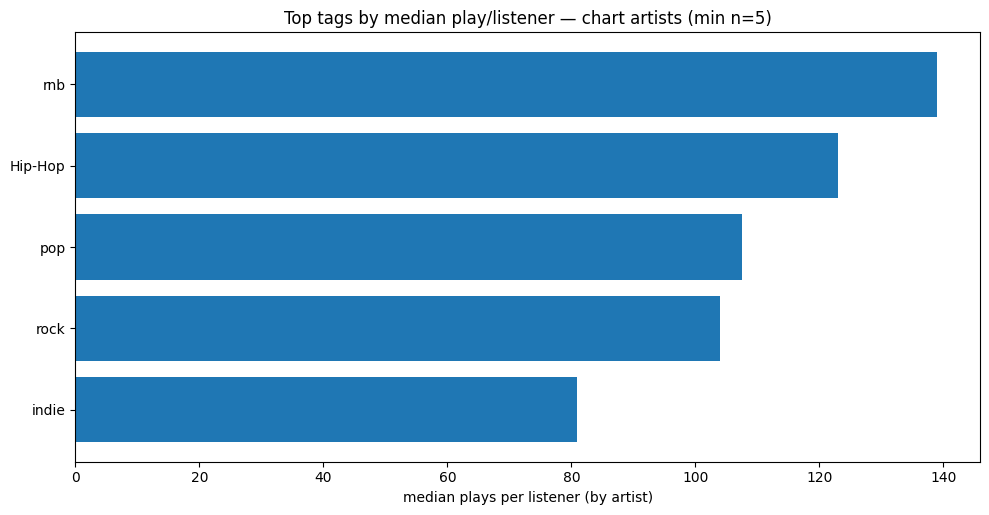

In [ ]:
# --- RQ3: aggregate by primary tag + visualization ---
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

MIN_ARTISTS_PER_TAG = 5
RQ3_TOP_K = 15

try:
    from IPython.display import display
except ImportError:
    display = print

_RQ3_ARTISTS_PKL = Path("rq3_artists_df.pkl")
if "rq3_artists_df" not in globals() or rq3_artists_df.empty:
    if _RQ3_ARTISTS_PKL.is_file():
        rq3_artists_df = pd.read_pickle(_RQ3_ARTISTS_PKL)
        print(
            f"Loaded rq3_artists_df from {_RQ3_ARTISTS_PKL} — re-run enrichment for fresh data."
        )
if "rq3_artists_df" not in globals() or rq3_artists_df.empty:
    raise RuntimeError(
        "rq3_artists_df is missing or empty. Run the RQ3 enrichment cell above first "
        "(artist.getinfo / artist.gettoptags). It saves rq3_artists_df.pkl next to this notebook."
    )

_g = (
    rq3_artists_df.groupby("genre_tag", sort=False)
    .agg(
        median_play_per_listener=("play_per_listener", "median"),
        n_artists=("play_per_listener", "count"),
        sum_play=("playcount", "sum"),
        sum_listen=("listeners", "sum"),
    )
    .reset_index()
)
_g["weighted_play_per_listener"] = _g["sum_play"] / _g["sum_listen"]

rq3_genre_summary = _g.loc[_g["n_artists"] >= MIN_ARTISTS_PER_TAG].sort_values(
    "median_play_per_listener", ascending=False
)

display(
    rq3_genre_summary.head(20)[
        [
            "genre_tag",
            "median_play_per_listener",
            "weighted_play_per_listener",
            "n_artists",
        ]
    ]
)

if rq3_genre_summary.empty:
    print(
        "No tags met the minimum artist count. "
        "Try lowering MIN_ARTISTS_PER_TAG or re-run when the API returns more tagged artists."
    )
else:
    _plot = rq3_genre_summary.head(RQ3_TOP_K).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, max(5, RQ3_TOP_K * 0.35)))
    ax.barh(_plot["genre_tag"].astype(str), _plot["median_play_per_listener"])
    ax.set_xlabel("median plays per listener (by artist)")
    ax.set_title(
        f"Top tags by median play/listener — chart artists (min n={MIN_ARTISTS_PER_TAG})"
    )
    plt.tight_layout()
    plt.show()

### Limitations (Research Question 3)

**Tags ≠ genres:** primary-tag assignment is a simplification; artists span multiple tags.

**Snapshot:** `chart.getTopArtists` changes over time; API **`playcount`** / **`listeners`** are Last.fm-specific, not global streams.

**Interpretation:** median play/listener compares typical intensity among chart artists with that primary tag; weighted ratio blends mega-artists differently—report both.

**Rate limits:** many per-artist calls; re-run may yield slightly different rankings if charts or tags shift.